In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
median_age = df['Age'].median()
print(f"Nilai Tengah (Median) umur penumpang: {median_age}")

df['Age'] = df['Age'].fillna(median_age)

Nilai Tengah (Median) umur penumpang: 28.0


In [4]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df[['Name', 'Sex', 'Age']].head()

,Name,Sex,Age
0,"Braund, Mr. Owen Harris",0,22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0
2,"Heikkinen, Miss. Laina",1,26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0
4,"Allen, Mr. William Henry",0,35.0


In [6]:
fitur_pilihan = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[fitur_pilihan]

Y = df['Survived']

print('Struktur Data Fitur X:')
print(X.head())
print('\nStruktur Data Target Y:')
print(Y.head())

Struktur Data Fitur X:
   Pclass  Sex   Age  SibSp  Parch     Fare
0       3    0  22.0      1      0   7.2500
1       1    1  38.0      1      0  71.2833
2       3    1  26.0      0      0   7.9250
3       1    1  35.0      1      0  53.1000
4       3    0  35.0      0      0   8.0500

Struktur Data Target Y:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [8]:
data_siap_pakai = X.copy()
data_siap_pakai['Survived'] = Y

data_siap_pakai.to_csv('../data/processed/data_siap_pakai.csv', index=False)
print("Selamat! File 'Titanic_data_siap_pakai.csv' telah berhasil disimpan dan siap uunmtuk tahap training model.")

Selamat! File 'Titanic_data_siap_pakai.csv' telah berhasil disimpan dan siap uunmtuk tahap training model.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latih: 712
Jumlah data uji: 179


In [13]:
from sklearn.ensemble import RandomForestClassifier

model =RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

print("Model berhasil dilatih dengan data latih.")

Model berhasil dilatih dengan data latih.


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
akurasi = accuracy_score(Y_test, y_pred)
print(f"Akurasi model pada data uji: {akurasi:.4f}")
print("\nLaporan Klasifikasi:")
print(classification_report(Y_test, y_pred))

Akurasi model pada data uji: 0.8045

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



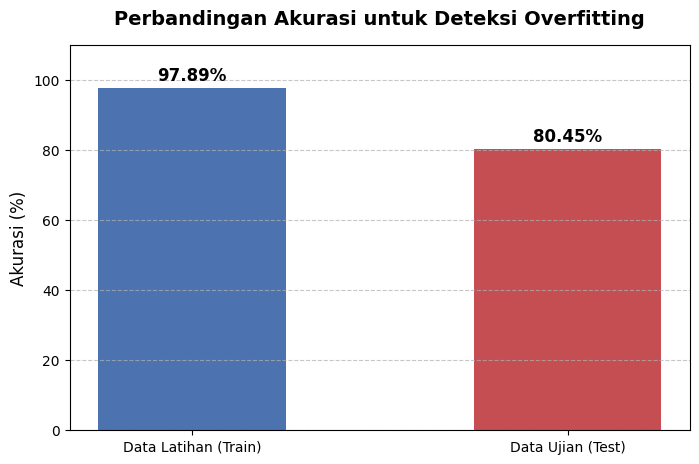

In [19]:
import matplotlib.pyplot as plt

# 1. Hitung ulang akurasi data latihan dan data uji (memastikan variabel siap)
akurasi_train = accuracy_score(Y_train, model.predict(X_train)) * 100
akurasi_test = accuracy_score(Y_test, model.predict(X_test)) * 100

# 2. Siapkan data untuk grafik
kategori = ['Data Latihan (Train)', 'Data Ujian (Test)']
nilai_akurasi = [akurasi_train, akurasi_test]
warna = ['#4C72B0', '#C44E52'] # Biru untuk train, Merah untuk test

# 3. Membuat plot menggunakan Matplotlib
plt.figure(figsize=(8, 5))
grafik = plt.bar(kategori, nilai_akurasi, color=warna, width=0.5)

# 4. Menambahkan teks angka persentase di atas setiap batang
for batang in grafik:
    tinggi = batang.get_height()
    plt.text(batang.get_x() + batang.get_width()/2., tinggi + 1,
             f'{tinggi:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Mengatur estetika chart (Judul dan Label)
plt.title('Perbandingan Akurasi untuk Deteksi Overfitting', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 110) # Membatasi tinggi grafik hingga 110% agar teks di atas tidak terpotong
plt.grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu tipis

# 6. Menampilkan grafik
plt.show()

In [21]:
import joblib

# Menyimpan model ke dalam file bernama 'model_titanic_pertama.pkl'
joblib.dump(model, '../models/model_titanic_pertama.pkl')

print("Model AI berhasil disimpan di folder models/!")

Model AI berhasil disimpan di folder models/!


In [23]:
import joblib
import pandas as pd

# Memuat kembali model dari folder models
model_terload = joblib.load('../models/model_titanic_pertama.pkl')
print("Model berhasil dimuat kembali dan siap bekerja!")

Model berhasil dimuat kembali dan siap bekerja!


In [25]:
# Membuat data baru berbentuk tabel (DataFrame)
penumpang_baru = pd.DataFrame([
    [3, 0, 22.0, 0, 0, 7.25],  # Data Budi
    [1, 1, 28.0, 1, 0, 71.28]  # Data Siti
], columns=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'])

# Menampilkan data penumpang baru
penumpang_baru

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,0,0,7.25
1,1,1,28.0,1,0,71.28


In [27]:
# Model menebak data penumpang baru
hasil_prediksi = model_terload.predict(penumpang_baru)

# Menerjemahkan angka hasil prediksi (0 = Meninggal, 1 = Selamat)
for i, hasil in enumerate(hasil_prediksi):
    nama_penumpang = "Budi" if i == 0 else "Siti"
    status = "SELAMAT" if hasil == 1 else "TIDAK SELAMAT"
    print(f"Hasil prediksi untuk {nama_penumpang}: {status}")
    

Hasil prediksi untuk Budi: TIDAK SELAMAT
Hasil prediksi untuk Siti: SELAMAT


In [28]:
# Menghitung probabilitas prediksi
peluang = model_terload.predict_proba(penumpang_baru)

for i, prob in enumerate(peluang):
    nama_penumpang = "Budi" if i == 0 else "Siti"
    print(f"Peluang {nama_penumpang} -> Wafat: {prob[0]*100:.2f}%, Selamat: {prob[1]*100:.2f}%")

Peluang Budi -> Wafat: 98.00%, Selamat: 2.00%
Peluang Siti -> Wafat: 4.00%, Selamat: 96.00%
